In [1]:
# Task 1: download and import dataset (5 Points) (1.1)

import pandas as pd

# reading the CSV file
mmgData = pd.read_csv('mammographic_masses_data.csv')

# displaying the first few rows of the DataFrame
print(mmgData.to_string())

      BA   Age  Shape  Margin  Density  Severity
0    5.0  67.0    3.0     5.0      3.0         1
1    4.0  43.0    1.0     1.0      NaN         1
2    5.0  58.0    4.0     5.0      3.0         1
3    4.0  28.0    1.0     1.0      3.0         0
4    5.0  74.0    1.0     5.0      NaN         1
5    4.0  65.0    1.0     NaN      3.0         0
6    4.0  70.0    NaN     NaN      3.0         0
7    5.0  42.0    1.0     NaN      3.0         0
8    5.0  57.0    1.0     5.0      3.0         1
9    5.0  60.0    NaN     5.0      1.0         1
10   5.0  76.0    1.0     4.0      3.0         1
11   3.0  42.0    2.0     1.0      3.0         1
12   4.0  64.0    1.0     NaN      3.0         0
13   4.0  36.0    3.0     1.0      2.0         0
14   4.0  60.0    2.0     1.0      2.0         0
15   4.0  54.0    1.0     1.0      3.0         0
16   3.0  52.0    3.0     4.0      3.0         0
17   4.0  59.0    2.0     1.0      3.0         1
18   4.0  54.0    1.0     1.0      3.0         1
19   4.0  40.0    1.

In [3]:
# with the shape fucntion we count the amount of rows and colums

mmgData.shape

(961, 6)

In [5]:
'''Task 2.1/3.1

with the notna function we removed all the rows that had a NaN in it, meaning that data was lost or either not recorded.
the all(axis) makes sure all colums have no null values anymore

So .notna() is very usefull to clean colums/rows with NAN values.

'''

mmgData_notnan = mmgData[mmgData[["Density", "Margin", "Shape", "BA", "Age", "Severity"]].notna().all(axis=1)]

mmgData_notnan = mmgData_notnan[mmgData_notnan['BA'] != 0]

print(mmgData_notnan.to_string())

      BA   Age  Shape  Margin  Density  Severity
0    5.0  67.0    3.0     5.0      3.0         1
2    5.0  58.0    4.0     5.0      3.0         1
3    4.0  28.0    1.0     1.0      3.0         0
8    5.0  57.0    1.0     5.0      3.0         1
10   5.0  76.0    1.0     4.0      3.0         1
11   3.0  42.0    2.0     1.0      3.0         1
13   4.0  36.0    3.0     1.0      2.0         0
14   4.0  60.0    2.0     1.0      2.0         0
15   4.0  54.0    1.0     1.0      3.0         0
16   3.0  52.0    3.0     4.0      3.0         0
17   4.0  59.0    2.0     1.0      3.0         1
18   4.0  54.0    1.0     1.0      3.0         1
21   5.0  56.0    4.0     3.0      1.0         1
23   5.0  42.0    4.0     4.0      3.0         1
24   4.0  59.0    2.0     4.0      3.0         1
25   5.0  75.0    4.0     5.0      3.0         1
28   5.0  45.0    4.0     5.0      3.0         1
29   5.0  55.0    4.0     4.0      3.0         0
30   4.0  46.0    1.0     5.0      2.0         0
31   5.0  54.0    4.

In [7]:
mmgData_notnan.shape

(829, 6)

In [9]:
# as can be seen here we lost 132 rows of data. But looking at that we have 829 out of 961 remaining that is only a 13.7% loss of data.

In [25]:
''' Task 2.2 '''

severity_margin = mmgData_notnan.loc[mmgData_notnan['Severity'] == 1, 'Margin']

print(severity_margin.to_string())

0      5.0
2      5.0
8      5.0
10     4.0
11     1.0
17     1.0
18     1.0
21     3.0
23     4.0
24     4.0
25     5.0
28     5.0
31     4.0
32     4.0
37     4.0
44     5.0
46     5.0
49     5.0
51     5.0
60     3.0
61     3.0
64     4.0
71     3.0
73     4.0
76     1.0
78     3.0
81     4.0
82     1.0
86     4.0
89     5.0
90     4.0
91     4.0
93     1.0
95     4.0
111    4.0
118    4.0
120    4.0
129    5.0
130    4.0
131    3.0
134    4.0
135    5.0
136    4.0
137    4.0
139    5.0
140    5.0
145    5.0
146    4.0
148    4.0
150    4.0
151    4.0
160    4.0
165    5.0
166    1.0
168    5.0
169    5.0
175    5.0
179    4.0
185    5.0
186    4.0
188    4.0
189    4.0
191    3.0
193    1.0
195    4.0
197    4.0
202    5.0
205    5.0
207    3.0
213    1.0
214    5.0
222    5.0
223    4.0
224    1.0
226    4.0
231    3.0
232    3.0
234    5.0
238    4.0
240    4.0
244    4.0
247    5.0
251    4.0
253    4.0
254    2.0
256    4.0
257    5.0
258    4.0
259    3.0
260    4.0
264    2.0

In [27]:
""" 
So following now we gonna look at what kind of summeries we can make, and try to find conclusions for this data.

Max we made were 3 correlations (if that is the right word), one is between Age and Severity. Trying to so see if
a certain age range has more seversere cases versus their non severe cases.

Next we can look if BA has any relationship with the shape. maybe saying a certain shap has a higher chance to be malignant.

finally Shape and density, see if there is a relation there and maybe bring it back to the BA and shape.
"""

' \nSo following now we gonna look at what kind of summeries we can make, and try to find conclusions for this data.\n\nMax we made were 3 correlations (if that is the right word), one is between Age and Severity. Trying to so see if\na certain age range has more seversere cases versus their non severe cases.\n\nNext we can look if BA has any relationship with the shape. maybe saying a certain shap has a higher chance to be malignant.\n\nfinally Shape and density, see if there is a relation there and maybe bring it back to the BA and shape.\n'

In [29]:
'''Task 2.1/2.3

Another set of usefull functions are the .groupby() and .mean().
.groupby() splits the informarion up in 2 colums.

.mean() is to take a bunch of values and than caluculates the average. Combining with groupby() with calculate the average of each group.

here we use panda's cut funtion to define the ranges and 20 to 110 and the taking steps by 10

'''

mmgData_notnan.loc[:, 'Age_Range'] = pd.cut(mmgData_notnan['Age'], bins=range(10, 110, 10), right=False)

# get the age ranges ina cloumm by group and calculate the average severity for each age range
age_severity = mmgData_notnan.groupby('Age_Range')['Severity'].mean().reset_index()

print(age_severity.to_string())


   Age_Range  Severity
0   [10, 20)  0.000000
1   [20, 30)  0.029412
2   [30, 40)  0.144737
3   [40, 50)  0.318471
4   [50, 60)  0.450237
5   [60, 70)  0.627451
6   [70, 80)  0.798077
7   [80, 90)  0.916667
8  [90, 100)  1.000000


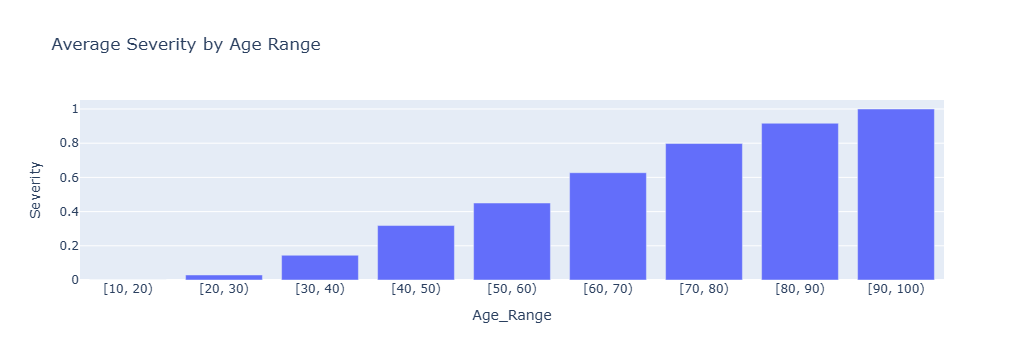

In [33]:
''' Task 2.3  '''

import plotly.express as px

# makes strings of the interavls of the age range so plotly can read it
age_severity['Age_Range'] = age_severity['Age_Range'].astype(str)

# creates the bar plot 
mmg_Bar = px.bar(age_severity, x='Age_Range', y='Severity', title='Average Severity by Age Range')

mmg_Bar.show()


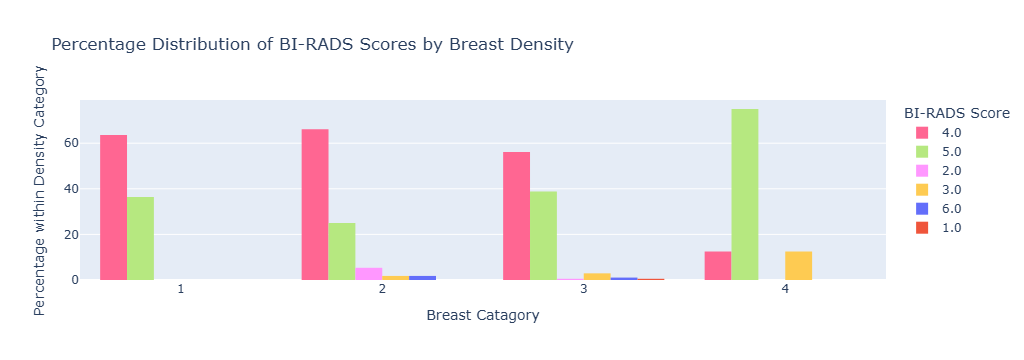

In [35]:
''' Task 2.3 '''

mmgData_notnan_filtered = mmgData_notnan[(mmgData_notnan['BA'] >= 1) & (mmgData_notnan['BA'] <= 6)]

grouped_data = mmgData_notnan_filtered.groupby(['Density', 'BA']).size().reset_index(name='count')

grouped_data['percentage'] = grouped_data['count'] / grouped_data.groupby('Density')['count'].transform('sum') * 100

fig = px.histogram(grouped_data, x='Density', y='percentage', color='BA', 
                   barmode='group', 
                   title="Percentage Distribution of BI-RADS Scores by Breast Density",
                   labels={"Density": "Density Catagory", "BA": "BI-RADS Score", "percentage": "Percentage (%)"},
                   category_orders={"Density": ['1', '2', '3', '4'], "BA": ['1', '2', '3', '4', '5', '6']})

fig.update_layout(
    xaxis_title="Breast Catagory",
    yaxis_title="Percentage within Density Category",
    legend_title="BI-RADS Score",
    bargap=0.2,
)

fig.show()


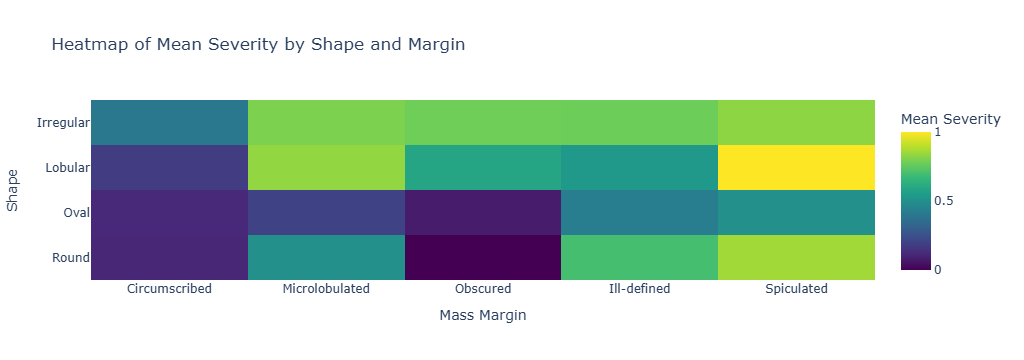

In [37]:
''' Task 2.3 '''

import plotly.graph_objects as go

shape_labels = {1: 'Round', 2: 'Oval', 3: 'Lobular', 4: 'Irregular'}
margin_labels = {1: 'Circumscribed', 2: 'Microlobulated', 3: 'Obscured', 4: 'Ill-defined', 5: 'Spiculated'}

grouped_dataheat = mmgData_notnan_filtered.groupby(['Shape', 'Margin'])['Severity'].mean().reset_index(name='mean_severity')

heatmap_data = grouped_dataheat.pivot(index='Shape', columns='Margin', values='mean_severity').fillna(0)

fig = go.Figure(data=go.Heatmap(
    z=heatmap_data.values,
    x=heatmap_data.columns,
    y=heatmap_data.index,
    colorscale='Viridis', 
    colorbar=dict(title='Mean Severity'),
    hoverongaps=False
))

fig.update_layout(
    title='Heatmap of Mean Severity by Shape and Margin',
    xaxis_title='Mass Margin',
    yaxis_title='Shape',
    xaxis=dict(
        tickmode='array',
        tickvals=[1, 2, 3, 4, 5],
        ticktext=[margin_labels[val] for val in [1, 2, 3, 4, 5]]
    ),
    yaxis=dict(
        tickmode='array',
        tickvals=[1, 2, 3, 4],
        ticktext=[shape_labels[val] for val in [1, 2, 3, 4]]
    )
)

fig.show()


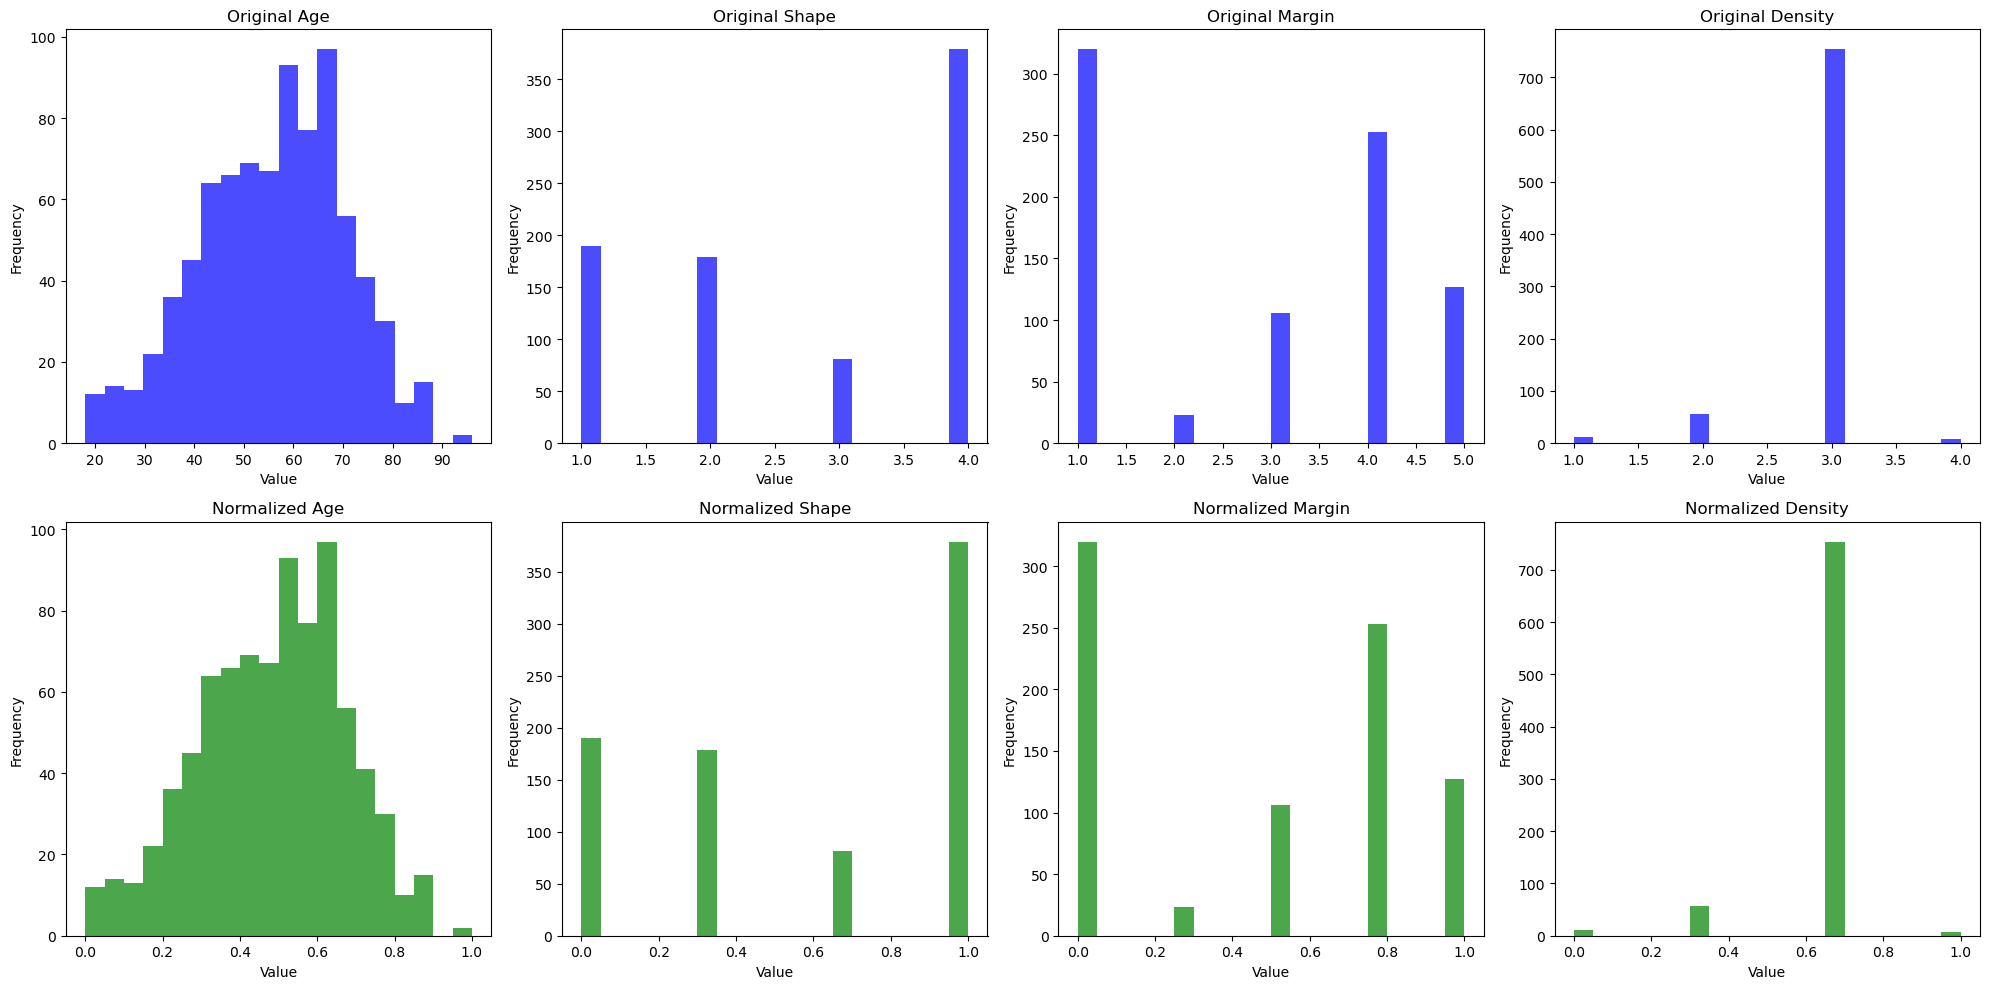

In [39]:
''' Task 3.2 '''

import numpy as np
import matplotlib.pyplot as plt

# normalization function
def min_max_normalize(column):
    min_val = column.min()
    max_val = column.max()
    return (column - min_val) / (max_val - min_val)

# use normalization for features
mmgData_normalized = mmgData_notnan.copy()
for feature in ['Age', 'Shape', 'Margin', 'Density']:
    if feature in mmgData_notnan.columns:
        mmgData_normalized[feature] = min_max_normalize(mmgData_notnan[feature])
    else:
        print(f"Feature '{feature}' not found in dataset.")

# set up subplots
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# plot original features
for i, feature in enumerate(['Age', 'Shape', 'Margin', 'Density']):
    if feature in mmgData_notnan.columns:
        axs[0, i].hist(mmgData_notnan[feature].dropna(), bins=20, color='blue', alpha=0.7)
        axs[0, i].set_title(f'Original {feature}')
        axs[0, i].set_xlabel('Value')
        axs[0, i].set_ylabel('Frequency')

# plot normalized
for i, feature in enumerate(['Age', 'Shape', 'Margin', 'Density']):
    if feature in mmgData_normalized.columns:
        axs[1, i].hist(mmgData_normalized[feature].dropna(), bins=20, color='green', alpha=0.7)
        axs[1, i].set_title(f'Normalized {feature}')
        axs[1, i].set_xlabel('Value')
        axs[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
''' Task 4.1 '''

from sklearn.feature_selection import SelectKBest, chi2

X = mmgData_notnan.drop(columns=['Severity'])
y = mmgData_notnan['Severity']

selector = SelectKBest(score_func=chi2, k='all')  # Use 'all' to get scores for all features
X_new = selector.fit_transform(X, y)

# feature scores and feature names
scores = selector.scores_
feature_names = X.columns

feature_scores = pd.DataFrame({
    'Feature': feature_names,
    'Score': scores
}).sort_values(by='Score', ascending=False)

fig = px.bar(feature_scores, x='Feature', y='Score', title="Feature Importance Using Chi-Squared Test")
fig.show()

print("Top features based on Univariate Selection:")
print(feature_scores)


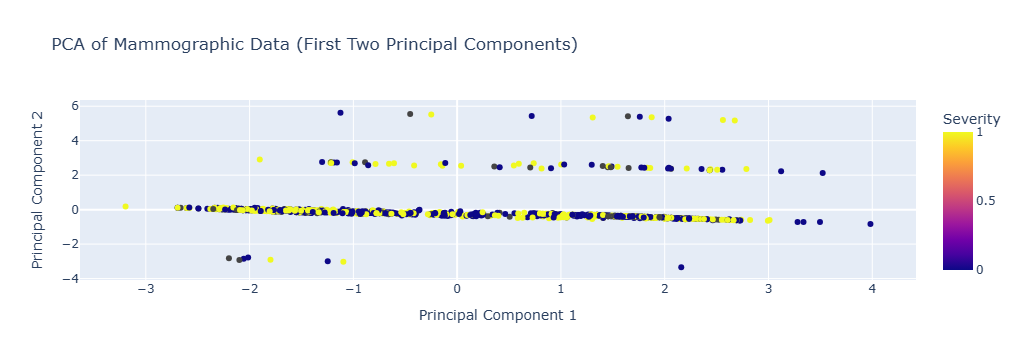

Explained variance ratio of each component: [0.48690641 0.19695726]


In [89]:
''' Task 4.2 '''

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# separate features and target variable (assuming 'Severity' is the target)
X = mmgData_notnan.drop(columns=['Severity'])
y = mmgData_notnan['Severity']

# standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# apply PCA to get less dimensions
pca = PCA(n_components=2)  # Keep only the first two principal components for visualization
X_pca = pca.fit_transform(X_scaled)

# create a DataFrame for the PCA result where we add the target variable 'Severity'
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Severity'] = y

fig = px.scatter(pca_df, x='PC1', y='PC2', color='Severity',
                 title='PCA of Mammographic Data (First Two Principal Components)',
                 labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'})
fig.show()

print("Explained variance ratio of each component:", pca.explained_variance_ratio_)


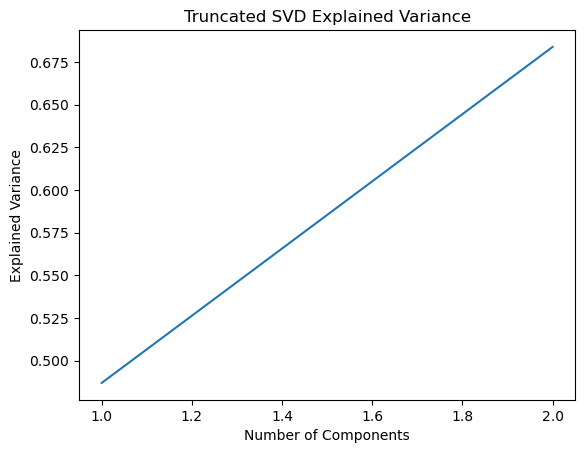

Explained variance ratio for each component: [0.48690641 0.19695726]


In [91]:
''' Task 4.3 '''

from sklearn.decomposition import TruncatedSVD

# separate features and target variable
X = mmgData_notnan.drop(columns=['Severity'])

# standard feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# use TruncatedSVD
k = 2
svd = TruncatedSVD(n_components=k)
X_svd = svd.fit_transform(X_scaled)

plt.plot(range(1, k + 1), np.cumsum(svd.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Truncated SVD Explained Variance')
plt.show()

print("Explained variance ratio for each component:", svd.explained_variance_ratio_)
